In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from file_management_lib import get_paths
from scipy.signal import find_peaks

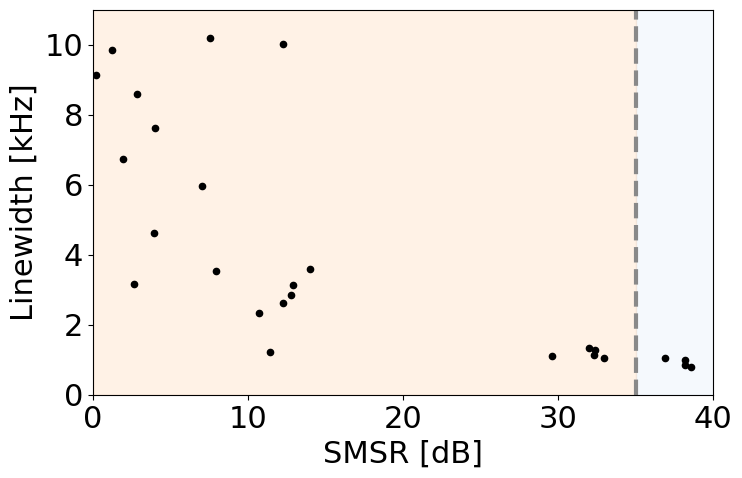

In [3]:
path = r".\Data\SMSR\2024-08-29_12-31-53\result.txt"

fontsize=22
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['lines.markersize'] = 9
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize

def get_data(path):
    df = pd.read_csv(path,header=3,
                     encoding="ISO-8859-1")
    lw = df.values[:,0]
    smsr = df.values[:,1]
    return lw, smsr

lw, smsr = get_data(path)

fig, ax = plt.subplots(figsize=[8,5])



props = dict(boxstyle='round', facecolor='wheat', alpha=1)

ax.add_patch(Rectangle((0, 0), 35, 35,alpha=.1,color='#FF800E'))
ax.add_patch(Rectangle((35, 0), 35, 35,alpha=.1,color='#A2C8EC'))

ax.set(xlabel='SMSR [dB]',
       ylabel='Linewidth [kHz]',
       xlim=[0,40],
       ylim=[0,11])

ax.axvline(35,linestyle='--',color='#898989')

ax.plot(smsr,lw/1e3,'.', color = 'black')

plt.savefig(r"O:\Tech_Photonics\Projects\Narrow Linewidth\MFB Chips\Chip 3 Feedback measurements\SPIE Prague 2025\Figures\linewidth_vs_smsr.svg",bbox_inches='tight')

array([-1.16928331e+01, -5.50809492e+00, -1.49998626e-04,  6.23078769e+00,
        1.16922331e+01])

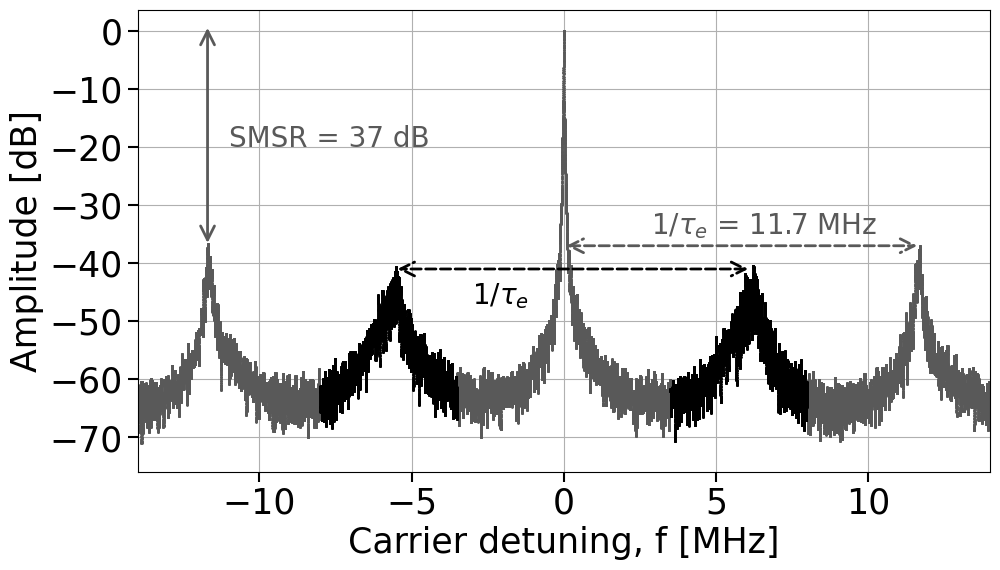

In [6]:
path = r".\Data\SMSR\2024-07-17_10-09-20_fb_15.2µW\no 20full.txt"
from cycler import cycler

fontsize = 25
plt.style.use('default')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.prop_cycle'] = cycler(color=['r', 'b', 'g', 'y','black','brown'])

plt.rcParams['legend.fontsize'] = fontsize
plt.rcParams['legend.loc'] = 'upper right'
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['xtick.minor.size'] = 4
plt.rcParams['xtick.minor.width'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.minor.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.major.size'] = 7
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['ytick.minor.size'] = 4

plt.rcParams['ytick.major.size'] = 7

# plt.rcParams["legend.framealpha"] = 1

def get_data(path,plot=False):
    df = np.loadtxt(path,skiprows=1,delimiter=',')
    freqs = df[0,:]/1e6 - 76
    ps = df[1,:]
    ps = ps - max(ps)
    if plot:
        plt.plot(freqs, ps)
    return freqs, ps

def plot_all(directory):
    for path in get_paths(directory):
        if 'full' in path:
            plt.figure()
            get_data(path)
            plt.title(path)

def plot_single(path,plot=False):
    freqs, ps = get_data(path)
    peaks, _ = find_peaks(ps,distance = 15000,threshold=-50)
    
    filt = (abs(freqs) > 3.5) & (abs(freqs) < 8)
    filt2 = (abs(freqs) < 3.5) ^ (abs(freqs) > 8)
    
    if plot:
        fig, ax = plt.subplots(figsize=(11,6))
        ax.set(xlabel='Carrier detuning, f [MHz]',
               ylabel='Amplitude [dB]',
               xlim=[-14, 14],
               yticks=[0, -10, -20, -30, -40, -50, -60, -70],
               xticks=[-10,-5,0,5,10])
        ax.grid()
        ax.plot(freqs[filt2],ps[filt2],'.',color='#595959',label = '1st sideband',markersize=2,rasterized=True)
        
        fsr = 11.7
        ax.annotate('', xy=(-fsr,-37), xytext=(-fsr,1), arrowprops=dict(arrowstyle='<->',linewidth=2,color='#595959'),fontsize=fontsize)
        ax.text(-11,-20,'SMSR = 37 dB',fontsize=20,color='#595959')
        ax.annotate('', xy=(fsr,-37), xytext=(0,-37), arrowprops=dict(arrowstyle='<->',linewidth=2,linestyle='--',color='#595959'),fontsize=fontsize)
        ax.annotate('', xy=(-fsr/2 +.3,-41), xytext=(fsr/2 +.3,-41), arrowprops=dict(arrowstyle='<->',linewidth=2,color='black',linestyle='--'),fontsize=fontsize)
        ax.text(-3,-47,'$1/\\tau_e$',fontsize=20,color='black')
        ax.text(fsr/2 - 3,-35,'$1/\\tau_e$ = ' + str(fsr) + ' MHz',fontsize=20,color='#595959')
        ax.plot(freqs[filt],ps[filt],'.', color='black',label='From DC',markersize=2,rasterized=True)
        black_line, = ax.plot([],[],color='#595959')
        grey_line, = ax.plot([],[],color='black')
    return freqs[peaks]

plot_single(path,plot=True)

# plt.savefig(r"O:\Tech_Photonics\Projects\Narrow Linewidth\MFB Chips\Chip 3 Feedback measurements\SPIE Prague 2025\Figures\FSR_SMSR.svg",bbox_inches='tight',dpi=900)